<a href="https://colab.research.google.com/github/Saiful-2/house-price-prediction/blob/main/notebooks/8_housing_feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

## 🔹 2. Load Dataset

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Saiful-2/datasets/main/ames_housing_cleaned.csv")

df.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,Ex,NaN,Shed,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,Ex,MnPrv,Shed,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,Ex,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,Ex,NaN,Shed,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,Ex,MnPrv,Shed,0,3,2010,WD,Normal,189900


## 🔹 3. Define Features & Target

In [5]:
target = "log_saleprice"
df[target] = np.log(df["saleprice"])
X = df.drop(columns=[target])
y = df[target]

## 🔹 4. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🔹 5. Preprocessing Pipeline (SAME as before)

In [7]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

## 🔹 6. Final Model

👉 From our evaluation notebook, Gradient Boosting is likely best

In [8]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

## 🔹 7. Train Model

In [9]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['ms_subclass', 'lot_frontage', 'lot_area', 'overall_qual',
       'overall_cond', 'year_built', 'year_remodadd', 'mas_vnr_area',
       'bsmtfin_sf_1', 'bsmtfin_sf_2', 'bsmt_unf_sf', 'total_bsmt_sf',
       '1st_flr_sf', '2nd_flr_sf', 'low_qual_fin_sf', 'gr_liv_area',
       'bsmt_full_bath', 'bsmt_hal...
       'bsmtfin_type_1', 'bsmtfin_type_2', 'heating', 'heating_qc',
       'central_air', 'electrical', 'kitchen_qual', 'functional',
       'fireplace_qu', 'garage_type', 'garage_finish', 'garage_qual',
       'garage_cond', 'paved_drive', 'pool_qc', 'fence', 'misc_feature',
       'sale_type', 'sale_condition'],
      dtype='object'))])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

## 🔹 8. Get Feature Names (CRITICAL STEP)

In [10]:
# Get OneHotEncoder
ohe = model.named_steps['preprocessor'].named_transformers_['cat']

# Get encoded categorical feature names
cat_features = ohe.get_feature_names_out(categorical_cols)

# Combine with numerical features
all_features = np.concatenate([numerical_cols, cat_features])

len(all_features)

300

## 🔹 9. Model-Based Feature Importance

In [11]:
importances = model.named_steps['regressor'].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
36,saleprice,9.999945e-01
26,garage_area,1.053183e-06
192,bsmt_qual_TA,4.226320e-07
4,overall_cond,3.833328e-07
7,mas_vnr_area,3.788494e-07
189,bsmt_qual_Fa,3.626564e-07
11,total_bsmt_sf,2.919857e-07
6,year_remodadd,2.443287e-07
159,exterior_2nd_HdBoard,2.437510e-07
1,lot_frontage,2.223529e-07


## 🔹 10. Top Features Plot

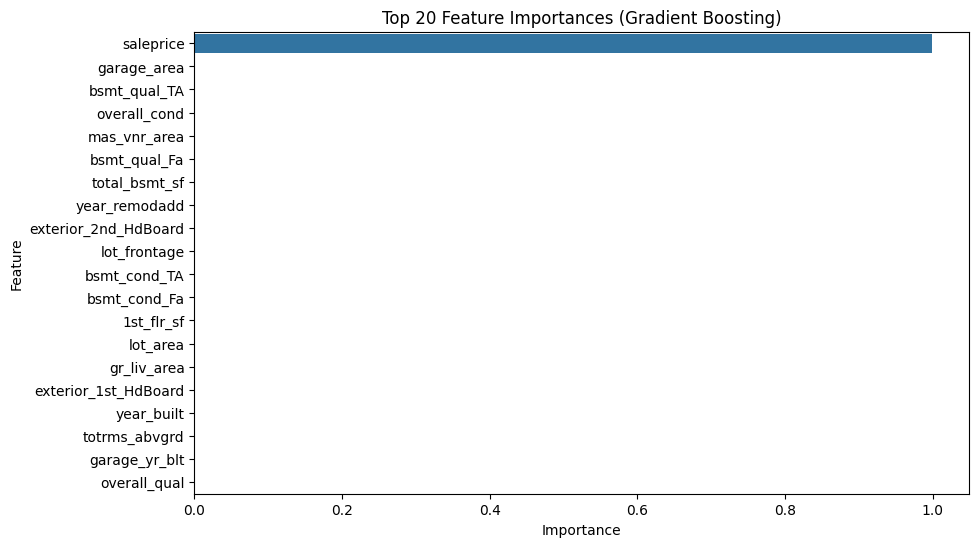

In [12]:
top_n = 20

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance_df.head(top_n),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Feature Importances (Gradient Boosting)")
plt.show()

## 🔹 11. Aggregate One-Hot Features

In [13]:
feature_importance_df["Base_Feature"] = feature_importance_df["Feature"].apply(
    lambda x: x.split("_")[0]
)

grouped_importance = feature_importance_df.groupby("Base_Feature")["Importance"].sum() \
    .sort_values(ascending=False)

grouped_importance.head(15)

,Importance
Base_Feature,
saleprice,9.999945e-01
bsmt,1.192713e-06
garage,1.189652e-06
overall,4.393997e-07
lot,3.907569e-07
exterior,3.819263e-07
mas,3.788494e-07
year,3.178805e-07
total,2.919857e-07


## 🔹 12. Aggregated Plot

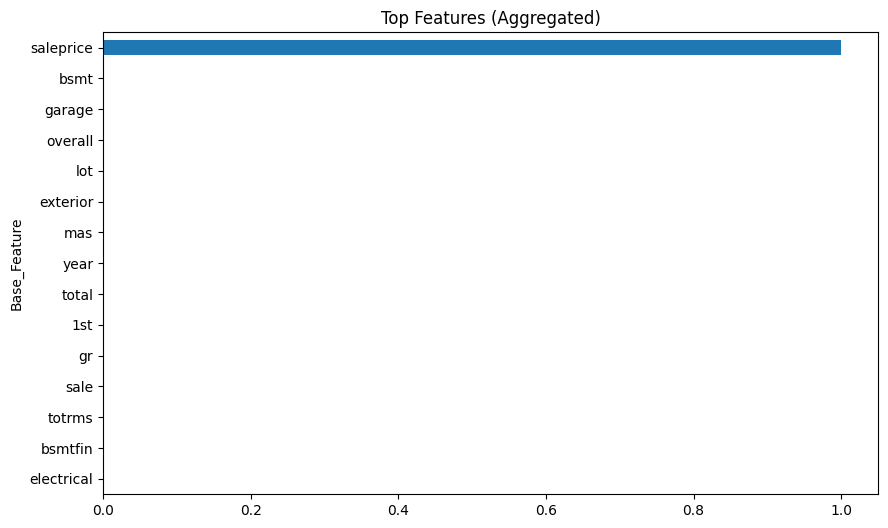

In [14]:
plt.figure(figsize=(10,6))
grouped_importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Features (Aggregated)")
plt.show()

## 🔹 13. Permutation Importance

In [16]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": X_test.columns, # Corrected to use the column names of X_test
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_importance_df.head(10)

,Feature,Importance
79,saleprice,2.039645e+00
29,bsmt_qual,3.336930e-06
61,garage_area,1.898884e-06
19,year_remodadd,1.092291e-06
2,lot_frontage,4.306145e-07
3,lot_area,4.008505e-07
23,exterior_2nd,3.301254e-07
42,1st_flr_sf,3.006463e-07
22,exterior_1st,2.063409e-07
58,garage_yr_blt,1.581371e-07


## 🔹 14. Permutation Plot

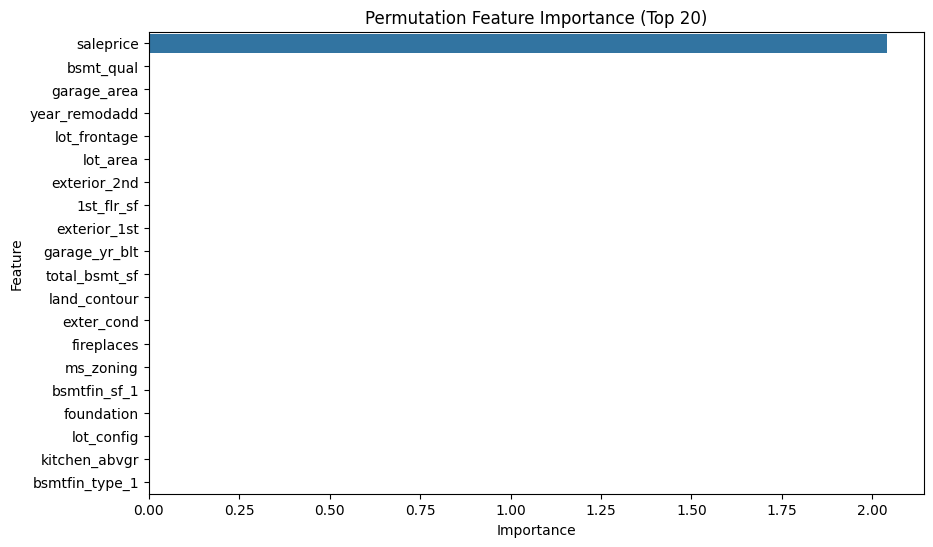

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=perm_importance_df.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Permutation Feature Importance (Top 20)")
plt.show()

## 🔹 15. Compare Both Methods

In [18]:
comparison = feature_importance_df.merge(
    perm_importance_df,
    on="Feature",
    suffixes=("_model", "_perm")
)

comparison.head(10)

,Feature,Importance_model,Base_Feature,Importance_perm
0,saleprice,9.999945e-01,saleprice,2.039645e+00
1,garage_area,1.053183e-06,garage,1.898884e-06
2,overall_cond,3.833328e-07,overall,-4.477305e-07
3,mas_vnr_area,3.788494e-07,mas,-2.490938e-08
4,total_bsmt_sf,2.919857e-07,total,7.503185e-08
5,year_remodadd,2.443287e-07,year,1.092291e-06
6,lot_frontage,2.223529e-07,lot,4.306145e-07
7,1st_flr_sf,1.544613e-07,1st,3.006463e-07
8,lot_area,1.455064e-07,lot,4.008505e-07
9,gr_liv_area,1.307421e-07,gr,-1.231197e-07


## 🔹 16. Save Results

In [19]:
feature_importance_df.to_csv("feature_importance_model.csv", index=False)
perm_importance_df.to_csv("feature_importance_permutation.csv", index=False)

## 17. Final Insights
## Feature Importance Insights

- Key drivers of house price:
  - Overall quality
  - Living area
  - Garage size
  - Neighborhood-related features

- Aggregated importance shows that:
  - Structural features dominate
  - Location-based features are highly influential

- Permutation importance confirms model-based importance reliability.

### Conclusion:
👉 House price is primarily driven by **quality, size, and location**.